# Cell 1 — Mount Drive + Extract Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

# Change this path to your dataset rar in Google Drive
ZIP_PATH = "/content/drive/MyDrive/dataset_drink_brand_logo.rar"

# Extraction directory
EXTRACT_DIR = "/content/dataset_drink_brand_logo"

# ============================================================
# EXTRACT DATASET
# ============================================================

if not os.path.exists(EXTRACT_DIR + "/detection"):
    os.makedirs(EXTRACT_DIR, exist_ok=True)

    # Use system unrar command to handle .rar files in Colab
    # 'x' extracts with full paths
    !unrar x "{ZIP_PATH}" "{EXTRACT_DIR}/"

    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

# ============================================================
# DATASET PATHS
# ============================================================

DATASET_DIR = Path(EXTRACT_DIR)

IMAGES_DIR = DATASET_DIR / "detection" / "images"
ANNOTATIONS_DIR = DATASET_DIR / "detection" / "annotations"
SPLITS_DIR = DATASET_DIR / "detection" / "splits"

TRAIN_TXT = SPLITS_DIR / "train.txt"
VAL_TXT   = SPLITS_DIR / "val.txt"
TEST_TXT  = SPLITS_DIR / "test.txt"

print(f"Dataset directory : {DATASET_DIR}")
print(f"Images directory  : {IMAGES_DIR}")
print(f"Annotations dir   : {ANNOTATIONS_DIR}")

# ============================================================
# VERIFY DATASET
# ============================================================

num_images = len(list(IMAGES_DIR.glob("*.jpg")))
num_xmls   = len(list(ANNOTATIONS_DIR.glob("*.xml")))

print("\n========== DATASET CHECK ==========")
print(f"Total Images      : {num_images}")
print(f"Total XML Files   : {num_xmls}")

print("\n========== SPLIT CHECK ==========")

for split_file in [TRAIN_TXT, VAL_TXT, TEST_TXT]:
    if split_file.exists():
        with open(split_file, 'r') as f:
            count = len(f.readlines())

        print(f"{split_file.stem.upper():<10}: {count} samples")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted.
Dataset directory : /content/dataset_drink_brand_logo
Images directory  : /content/dataset_drink_brand_logo/detection/images
Annotations dir   : /content/dataset_drink_brand_logo/detection/annotations

========== DATASET CHECK ==========
Total Images      : 2980
Total XML Files   : 2980

========== SPLIT CHECK ==========
TRAIN     : 2384 samples
VAL       : 298 samples
TEST      : 298 samples


# Cell 2 — Import Library + Dataset Statistics

In [5]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xml.etree.ElementTree as ET

from tqdm import tqdm
from collections import Counter

# ============================================================
# LOAD SPLITS
# ============================================================

def load_split(txt_path):
    with open(txt_path, 'r') as f:
        names = [line.strip() for line in f.readlines()]
    return names

train_files = load_split(TRAIN_TXT)
val_files   = load_split(VAL_TXT)
test_files  = load_split(TEST_TXT)

# ============================================================
# XML PARSER
# ============================================================

def parse_voc_xml(xml_path):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text

    size = root.find("size")

    width  = int(size.find("width").text)
    height = int(size.find("height").text)

    objects = []

    for obj in root.findall("object"):

        label = obj.find("name").text

        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        area = (xmax - xmin) * (ymax - ymin)

        objects.append({
            "label": label,
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax,
            "bbox_area": area
        })

    return {
        "filename": filename,
        "width": width,
        "height": height,
        "num_objects": len(objects),
        "objects": objects
    }

# ============================================================
# ANALYZE DATASET
# ============================================================

xml_files = sorted(list(ANNOTATIONS_DIR.glob("*.xml")))

dataset_info = []
all_labels = []
bbox_areas = []
objects_per_image = []

for xml_file in tqdm(xml_files):

    info = parse_voc_xml(xml_file)

    dataset_info.append(info)

    objects_per_image.append(info["num_objects"])

    for obj in info["objects"]:

        all_labels.append(obj["label"])
        bbox_areas.append(obj["bbox_area"])

# ============================================================
# BASIC STATISTICS
# ============================================================

label_counter = Counter(all_labels)

print("========== DATASET STATISTICS ==========\n")

print(f"Total Images             : {len(dataset_info)}")
print(f"Total Objects            : {len(all_labels)}")
print(f"Average Objects/Image    : {np.mean(objects_per_image):.2f}")

print("\n========== LABEL DISTRIBUTION ==========\n")

for label, count in label_counter.items():
    print(f"{label:<15}: {count}")

print("\n========== BOUNDING BOX AREA ==========\n")

print(f"Min Area                 : {np.min(bbox_areas)}")
print(f"Max Area                 : {np.max(bbox_areas)}")
print(f"Mean Area                : {np.mean(bbox_areas):.2f}")

100%|██████████| 2980/2980 [00:00<00:00, 17879.10it/s]

========== DATASET STATISTICS ==========

Total Images             : 2980
Total Objects            : 5995
Average Objects/Image    : 2.01

========== LABEL DISTRIBUTION ==========

logo           : 5995

========== BOUNDING BOX AREA ==========

Min Area                 : 0
Max Area                 : 407682
Mean Area                : 18435.45


# Cell 3 — Visualization Dataset Distribution + Sample Images

/tmp/ipykernel_17302/4025560041.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


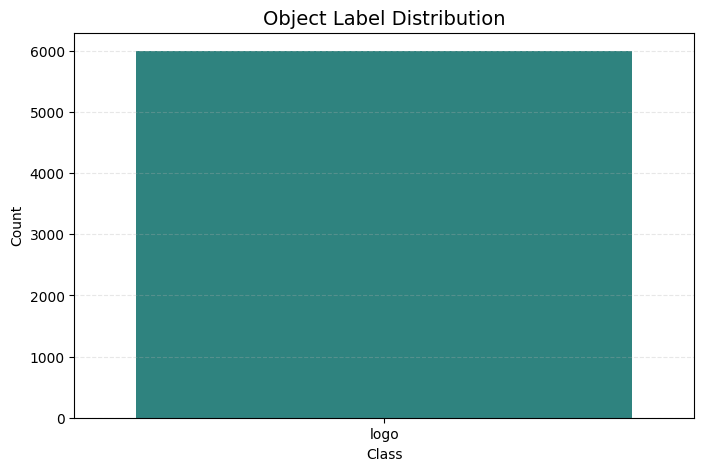

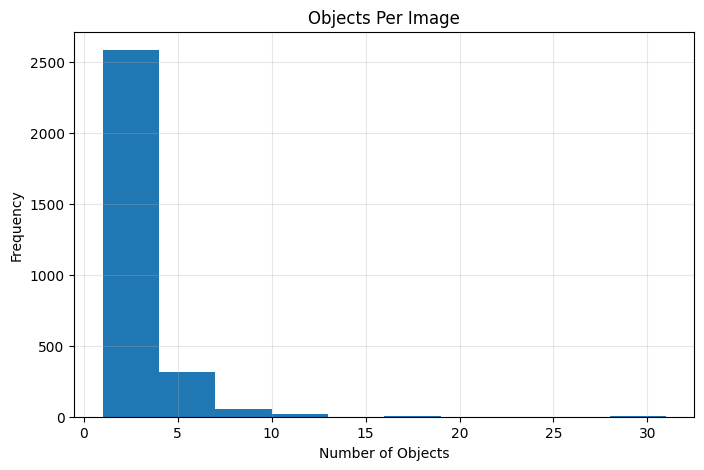

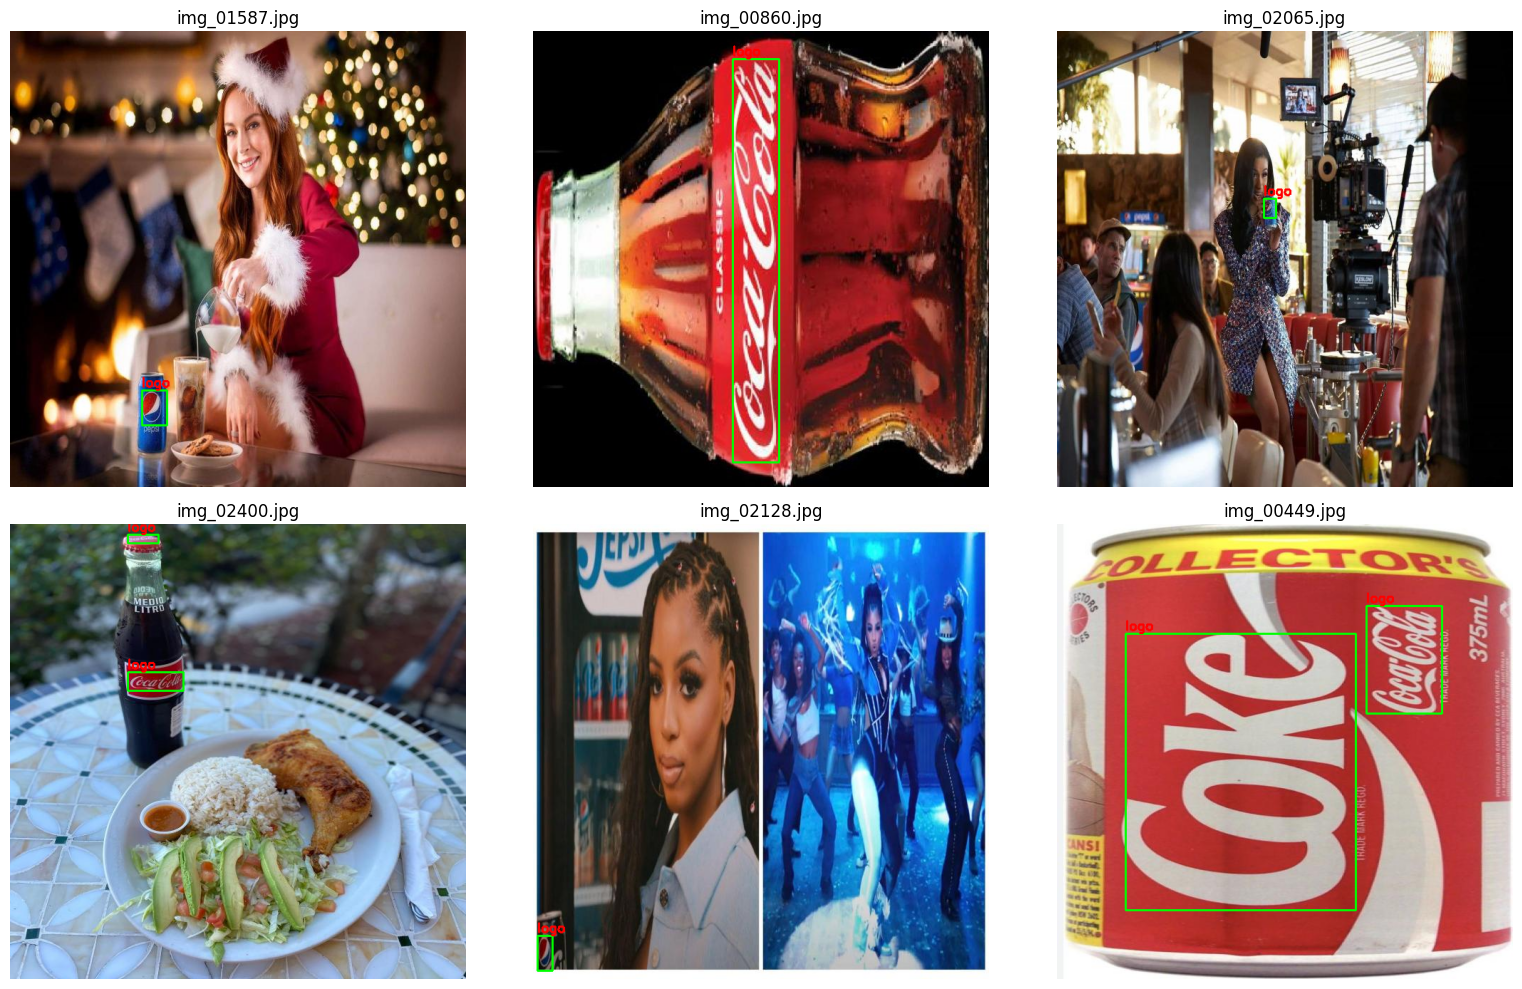

In [6]:
import random

# ============================================================
# OBJECT DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x=all_labels,
    palette="viridis"
)

plt.title("Object Label Distribution", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Count")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

# ============================================================
# OBJECTS PER IMAGE
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    objects_per_image,
    bins=10
)

plt.title("Objects Per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# SAMPLE VISUALIZATION
# ============================================================

sample_xmls = random.sample(xml_files, 6)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, xml_file in zip(axes, sample_xmls):

    info = parse_voc_xml(xml_file)

    image_path = IMAGES_DIR / info["filename"]

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Draw bounding boxes
    for obj in info["objects"]:

        xmin = obj["xmin"]
        ymin = obj["ymin"]
        xmax = obj["xmax"]
        ymax = obj["ymax"]

        cv2.rectangle(
            image,
            (xmin, ymin),
            (xmax, ymax),
            (0,255,0),
            2
        )

        cv2.putText(
            image,
            obj["label"],
            (xmin, ymin-5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,0,0),
            2
        )

    ax.imshow(image)
    ax.set_title(info["filename"])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Cell 4 — In-depth Image Analysis (Size, Channel, Brightness)

100%|██████████| 2980/2980 [00:06<00:00, 430.34it/s]


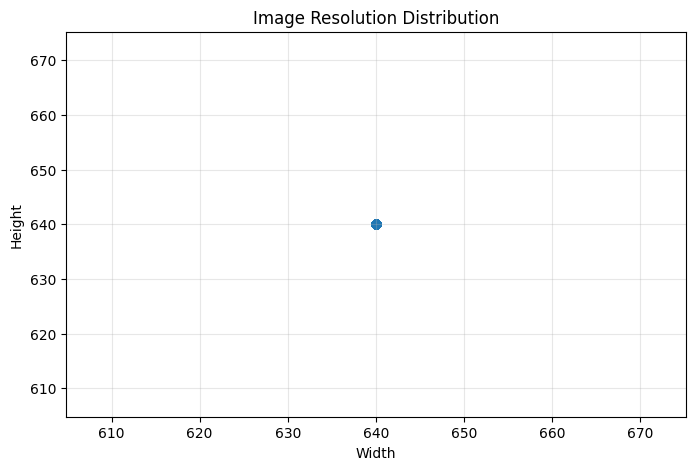

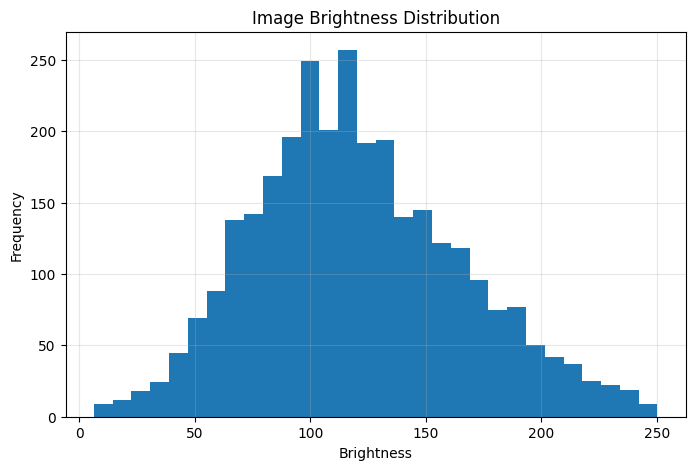

========== CHANNEL DISTRIBUTION ==========

3 channels : 2980 images

========== IMAGE SIZE SUMMARY ==========

Min Width      : 640
Max Width      : 640
Min Height     : 640
Max Height     : 640
Average Width  : 640.00
Average Height : 640.00

========== BRIGHTNESS SUMMARY ==========

Min Brightness     : 6.27
Max Brightness     : 250.22
Average Brightness : 120.19


In [7]:
image_shapes = []
brightness_values = []
channels = []

# ============================================================
# IMAGE ANALYSIS
# ============================================================

image_files = sorted(list(IMAGES_DIR.glob("*.jpg")))

for image_path in tqdm(image_files):

    image = cv2.imread(str(image_path))

    if image is None:
        continue

    h, w, c = image.shape

    image_shapes.append((w, h))
    channels.append(c)

    # Brightness
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    brightness = gray.mean()

    brightness_values.append(brightness)

# ============================================================
# IMAGE SIZE DISTRIBUTION
# ============================================================

widths  = [shape[0] for shape in image_shapes]
heights = [shape[1] for shape in image_shapes]

plt.figure(figsize=(8,5))

plt.scatter(widths, heights, alpha=0.5)

plt.title("Image Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# BRIGHTNESS DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    brightness_values,
    bins=30
)

plt.title("Image Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# CHANNEL ANALYSIS
# ============================================================

channel_counter = Counter(channels)

print("========== CHANNEL DISTRIBUTION ==========\n")

for channel, count in channel_counter.items():
    print(f"{channel} channels : {count} images")

# ============================================================
# IMAGE SIZE SUMMARY
# ============================================================

print("\n========== IMAGE SIZE SUMMARY ==========\n")

print(f"Min Width      : {np.min(widths)}")
print(f"Max Width      : {np.max(widths)}")

print(f"Min Height     : {np.min(heights)}")
print(f"Max Height     : {np.max(heights)}")

print(f"Average Width  : {np.mean(widths):.2f}")
print(f"Average Height : {np.mean(heights):.2f}")

# ============================================================
# BRIGHTNESS SUMMARY
# ============================================================

print("\n========== BRIGHTNESS SUMMARY ==========\n")

print(f"Min Brightness     : {np.min(brightness_values):.2f}")
print(f"Max Brightness     : {np.max(brightness_values):.2f}")
print(f"Average Brightness : {np.mean(brightness_values):.2f}")

# Cell 5 — RGB Statistics + Dataset Summary

100%|██████████| 2980/2980 [00:08<00:00, 350.45it/s]


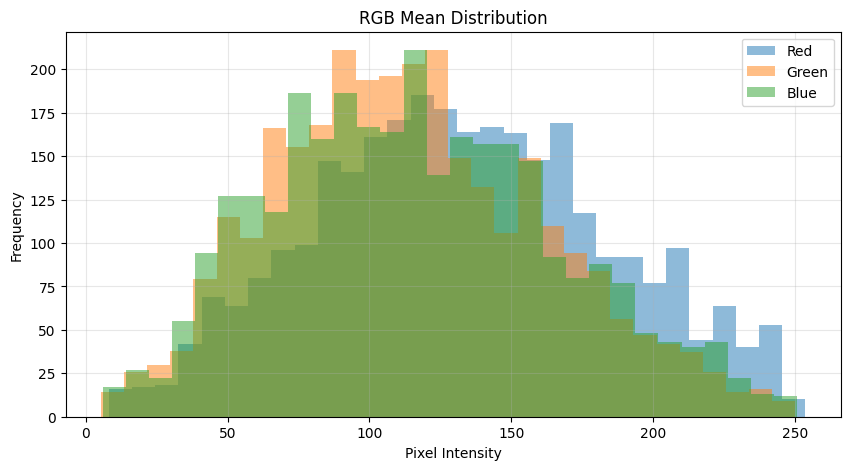

========== RGB CHANNEL STATISTICS ==========

Mean Red Channel   : 132.94
Mean Green Channel : 114.45
Mean Blue Channel  : 116.27

========== FINAL DATASET SUMMARY ==========



,Metric,Value
0,Total Images,2980.00
1,Total XML Files,2980.00
2,Total Objects,5995.00
3,Average Objects/Image,2.01
4,Average Width,640.00
5,Average Height,640.00
6,Average Brightness,120.19


In [8]:
# ============================================================
# RGB STATISTICS
# ============================================================

mean_r = []
mean_g = []
mean_b = []

for image_path in tqdm(image_files):

    image = cv2.imread(str(image_path))

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mean_r.append(image[:,:,0].mean())
    mean_g.append(image[:,:,1].mean())
    mean_b.append(image[:,:,2].mean())

# ============================================================
# RGB DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

plt.hist(mean_r, bins=30, alpha=0.5, label='Red')
plt.hist(mean_g, bins=30, alpha=0.5, label='Green')
plt.hist(mean_b, bins=30, alpha=0.5, label='Blue')

plt.title("RGB Mean Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# RGB SUMMARY
# ============================================================

print("========== RGB CHANNEL STATISTICS ==========\n")

print(f"Mean Red Channel   : {np.mean(mean_r):.2f}")
print(f"Mean Green Channel : {np.mean(mean_g):.2f}")
print(f"Mean Blue Channel  : {np.mean(mean_b):.2f}")

# ============================================================
# DATASET SUMMARY
# ============================================================

summary_df = pd.DataFrame({
    "Metric": [
        "Total Images",
        "Total XML Files",
        "Total Objects",
        "Average Objects/Image",
        "Average Width",
        "Average Height",
        "Average Brightness"
    ],
    "Value": [
        len(dataset_info),
        len(xml_files),
        len(all_labels),
        round(np.mean(objects_per_image), 2),
        round(np.mean(widths), 2),
        round(np.mean(heights), 2),
        round(np.mean(brightness_values), 2)
    ]
})

print("\n========== FINAL DATASET SUMMARY ==========\n")

display(summary_df)